# Generate all csv files only

In [12]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp
workload_dir = './workload'
csv_dir = './csv'


# Run gen_data.py to generate data.csv
print("Running gen_data.py...")
subprocess.run([
    'python3', './gen_py/gen_data.py',
    '-o', os.path.join(csv_dir, 'data.csv'),
    '-n', '1000', '-k', '8', '-p', '8', '-vmin', '32', '-vmax', '64', '-s', '5'
], check=True)
print("data.csv generated.")

# Generate workloads (txs and ops files)
print("Generating workloads...")
subprocess.run(['python3', './gen_py/gen_workloads.py'], check=True)
print("Workloads generated.")

# Generate data after ops for each workload (producing workload-specific *_recent_data_after_ops.csv and *_history_data_after_ops.csv)
print("Generating data after ops for each workload (via gen_workloads_results.py)...")
subprocess.run(['python3', './gen_py/gen_workloads_results.py'], check=True)
print("Workloads results generated.")

Running gen_data.py...
data.csv generated.
Generating workloads...
Generated 1000 transactions in csv/read_only_txs.csv
Generated mixed operations in csv/read_only_ops.csv
Generated 1000 transactions in csv/update_only_txs.csv
Generated mixed operations in csv/update_only_ops.csv
Generated 1000 transactions in csv/insert_only_txs.csv
Generated mixed operations in csv/insert_only_ops.csv
Generated 1000 transactions in csv/insert20_update60_delete20_txs.csv
Generated mixed operations in csv/insert20_update60_delete20_ops.csv
Generated 1000 transactions in csv/read50_insert_50_txs.csv
Generated mixed operations in csv/read50_insert_50_ops.csv
Workloads generated.
Generating data after ops for each workload (via gen_workloads_results.py)...
No txs file found for workload insert20_update60_delete20_history_data_after, skipping...
Processing workload insert20_update60_delete20 with gen_data_after_txs.py...

Processing transactions (txs.csv)...
Generated recent data in csv/insert20_update60_d

Building hash_join_bench with cargo build --release...
Build completed.
Missing recent/history after ops files for workload insert20_update60_delete20_history_data_after, skipping benchmark.
Running benchmark for workload insert20_update60_delete20, run 1...


    Finished `release` profile [optimized + debuginfo] target(s) in 0.03s


Running benchmark for workload insert20_update60_delete20, run 2...
Missing recent/history after ops files for workload insert20_update60_delete20_recent_data_after, skipping benchmark.
Missing recent/history after ops files for workload insert_only_history_data_after, skipping benchmark.
Running benchmark for workload insert_only, run 1...
Running benchmark for workload insert_only, run 2...
Missing recent/history after ops files for workload insert_only_recent_data_after, skipping benchmark.
Missing recent/history after ops files for workload read50_insert_50_history_data_after, skipping benchmark.
Running benchmark for workload read50_insert_50, run 1...
Running benchmark for workload read50_insert_50, run 2...
Missing recent/history after ops files for workload read50_insert_50_recent_data_after, skipping benchmark.
Missing recent/history after ops files for workload read_only_history_data_after, skipping benchmark.
Running benchmark for workload read_only, run 1...
Running benchma

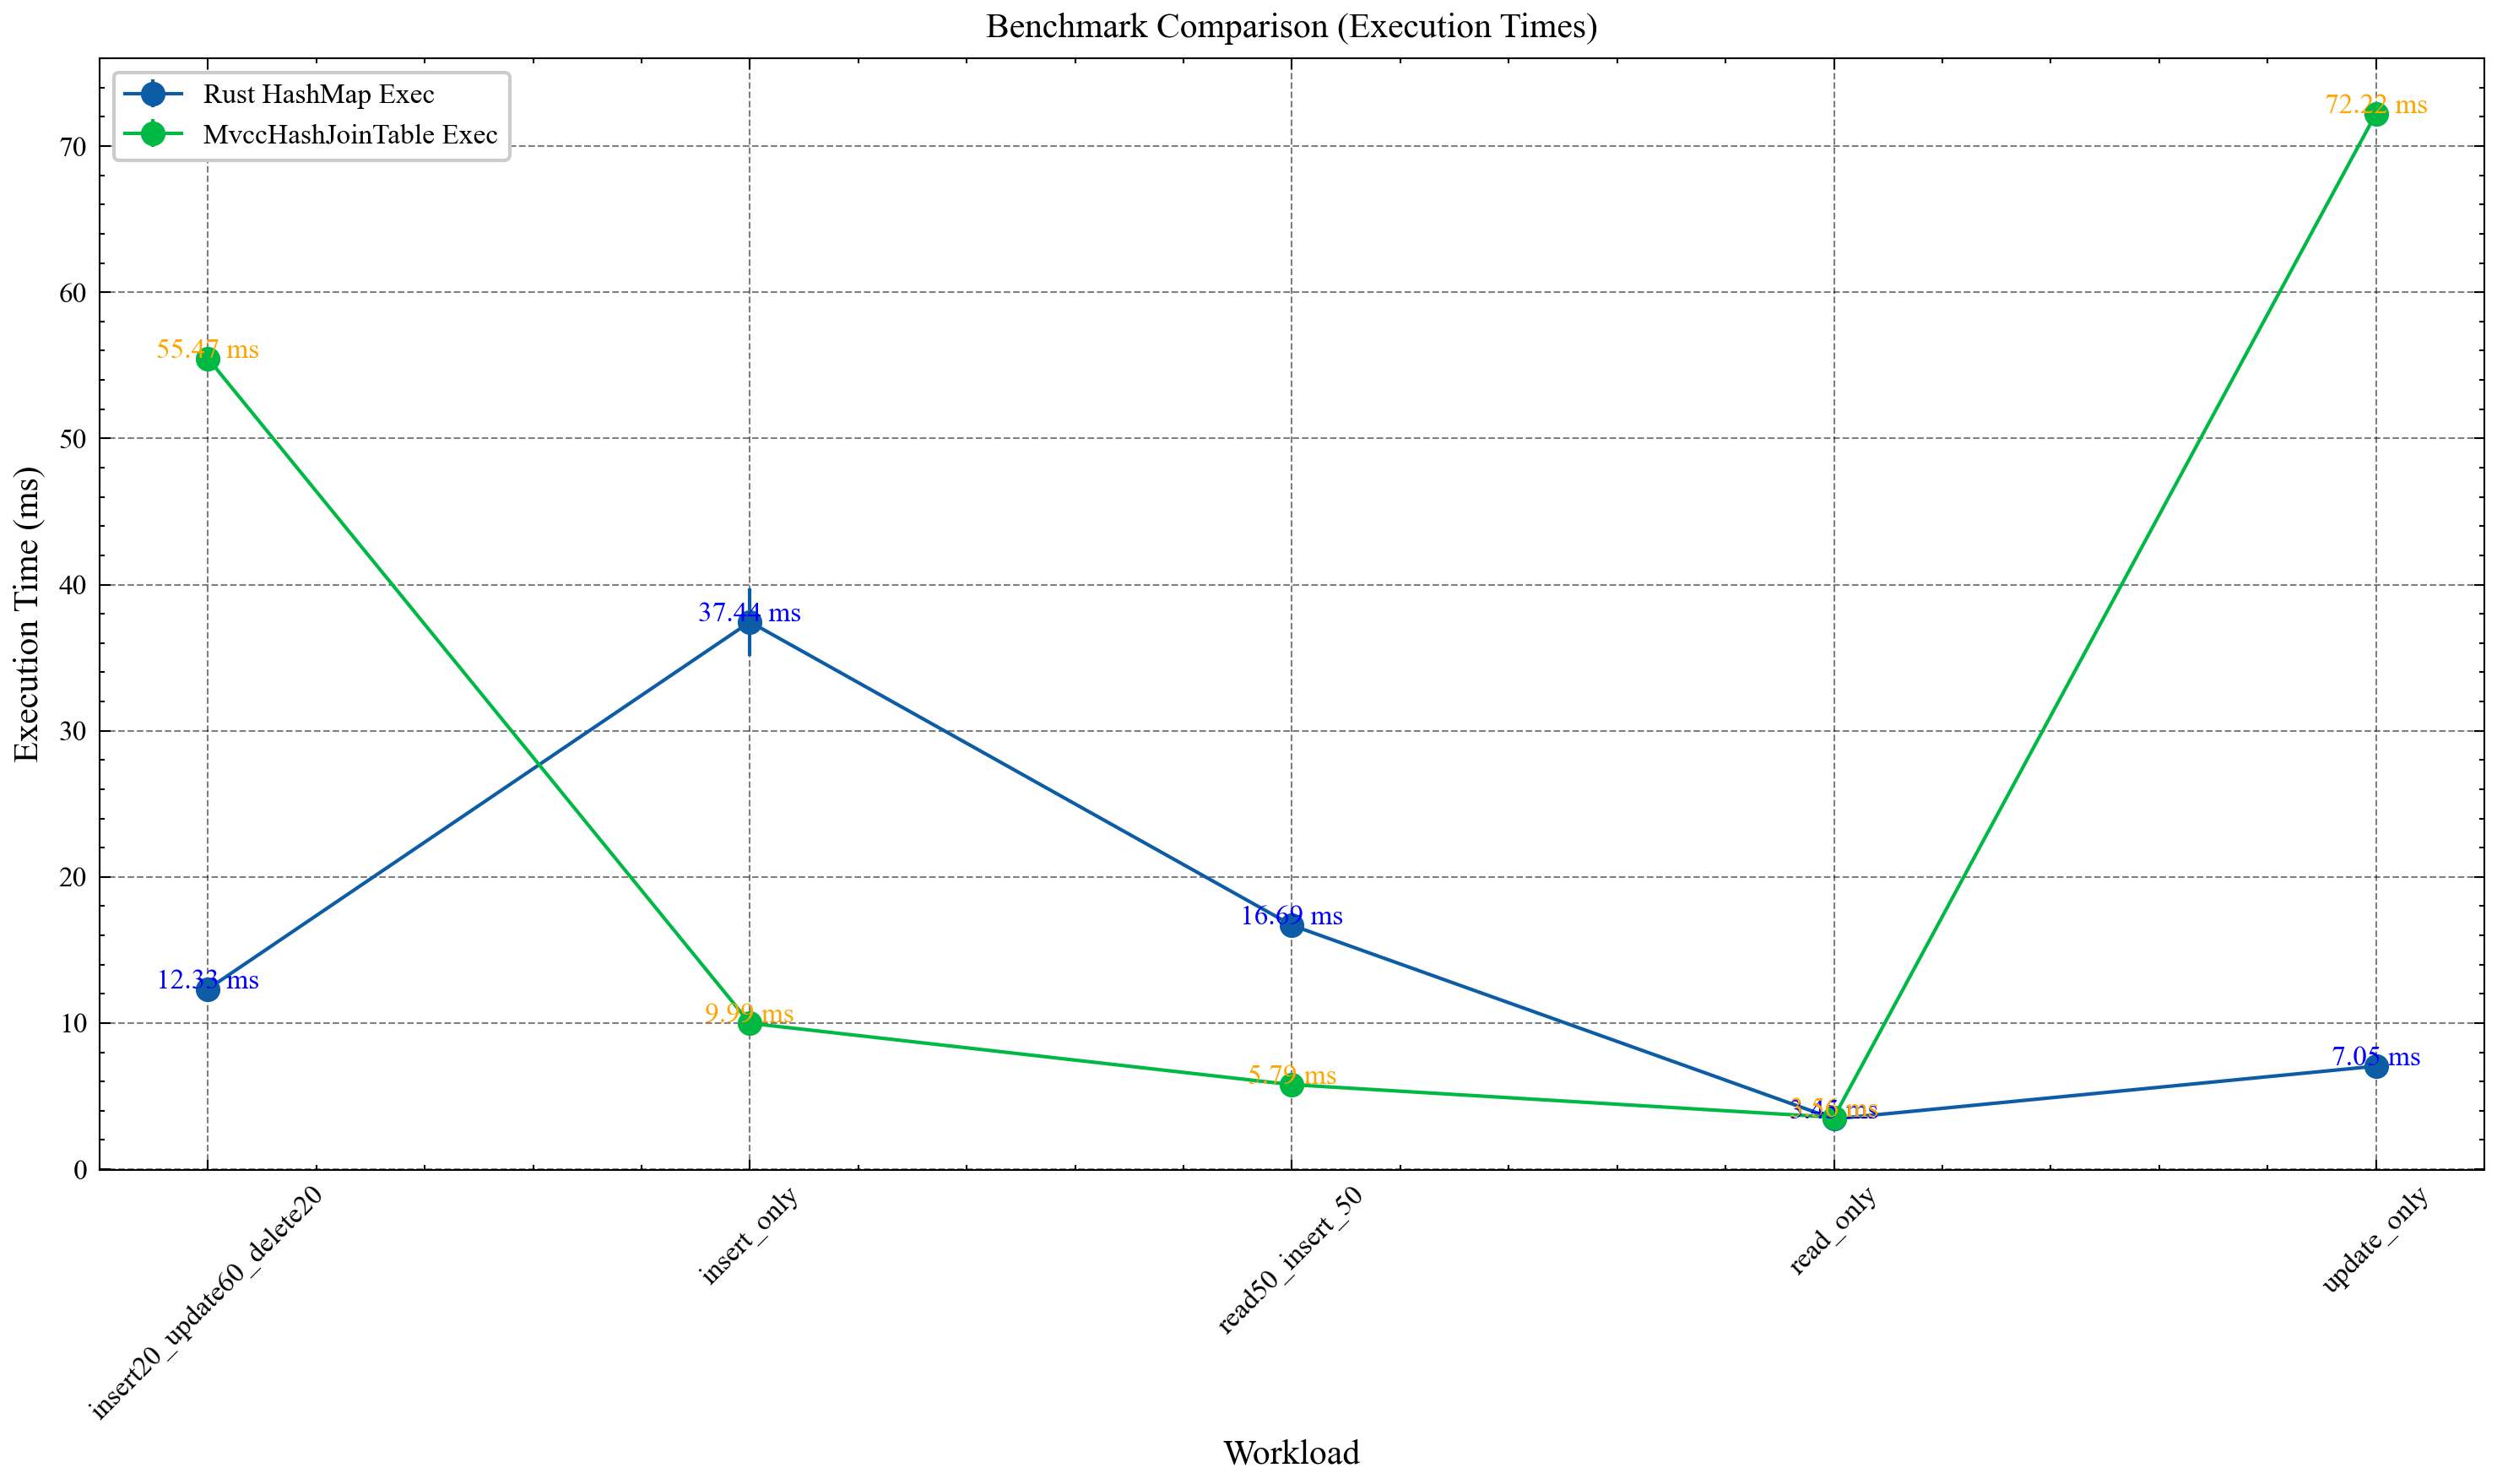

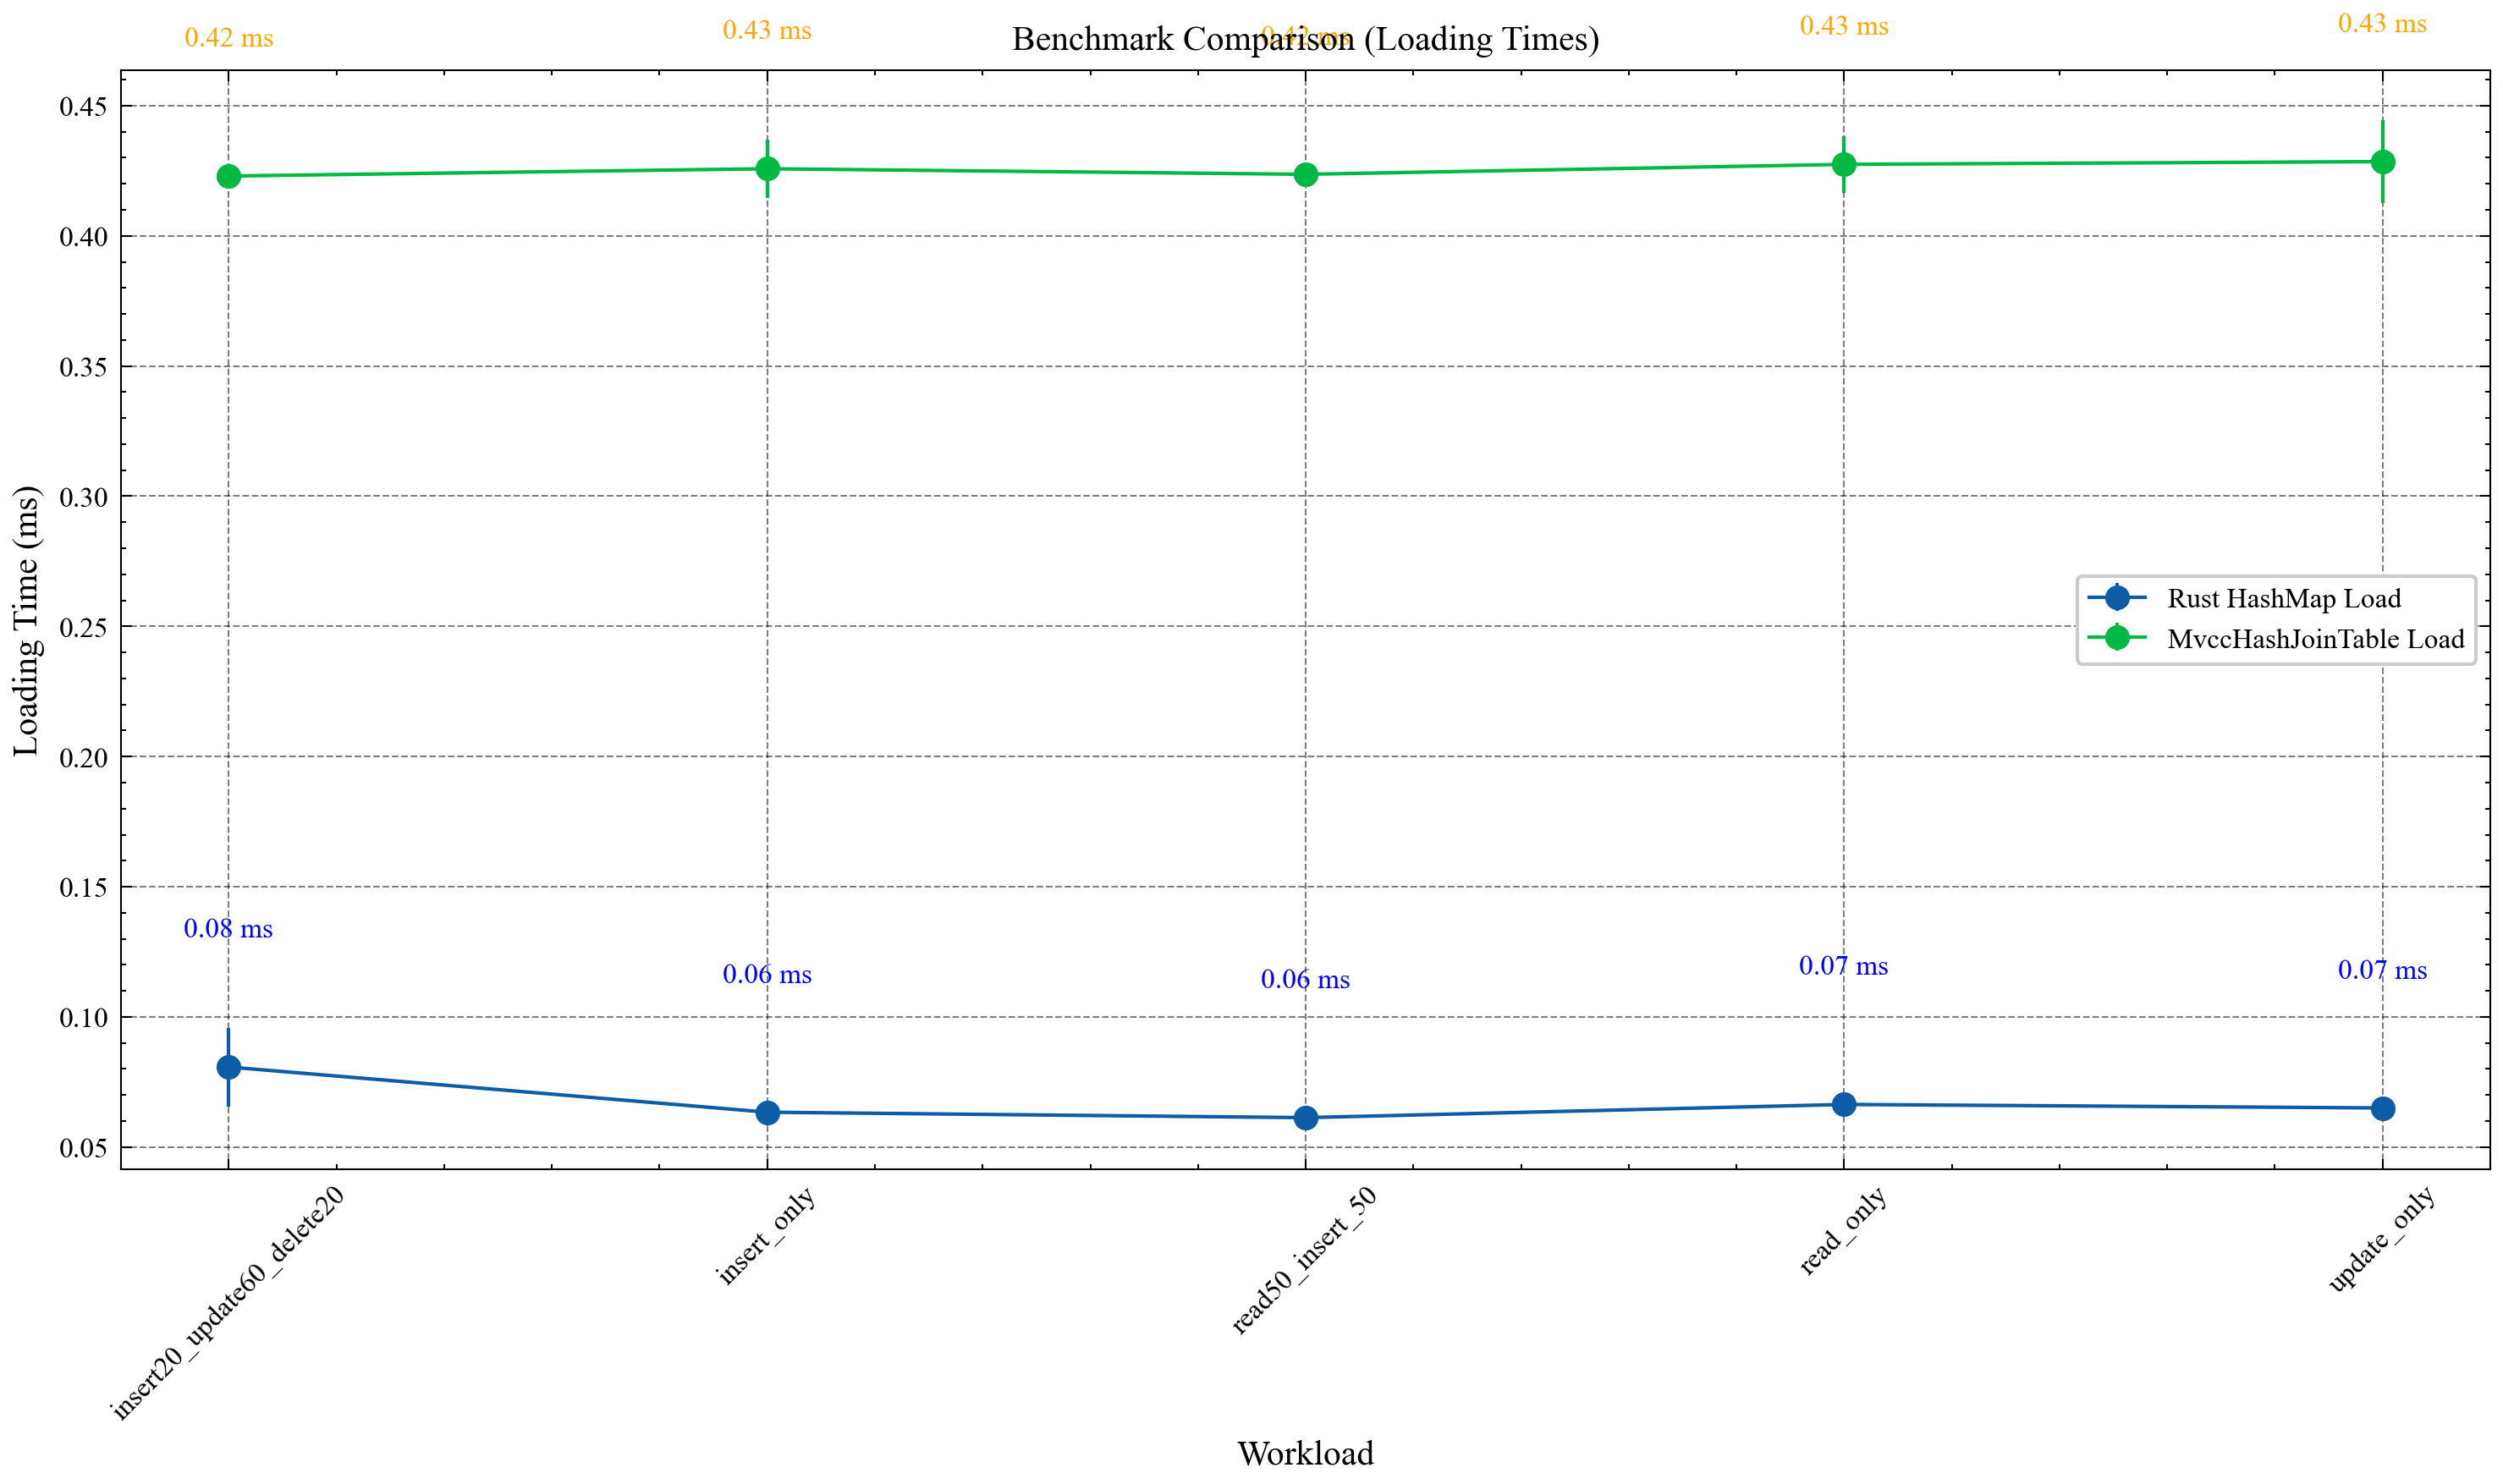

In [14]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp

# Use the custom style
plt.style.use('custom_plt_sytle.mplstyle')

# Number of runs per workload
n = 2

workload_dir = './workload'
csv_dir = './csv'



# Build the binary to ensure it's up-to-date
myenv = os.environ.copy()
myenv["RUSTFLAGS"] = "-Awarnings"
print("Building hash_join_bench with cargo build --release...")
subprocess.run(['cargo', 'build', '--release', '--bin', 'hash_join_bench'], check=True, env=myenv)
print("Build completed.")

# # Clean up old CSV files in workload and csv directories
# for f in glob.glob(os.path.join(workload_dir, '*.csv')):
#     os.remove(f)
# for f in glob.glob(os.path.join(csv_dir, '*.csv')):
#     os.remove(f)

# print("Deleted existing CSV files.")

# # Run gen_data.py to generate data.csv
# print("Running gen_data.py...")
# subprocess.run([
#     'python3', './gen_py/gen_data.py',
#     '-o', os.path.join(csv_dir, 'data.csv'),
#     '-n', '1000', '-k', '8', '-p', '8', '-vmin', '32', '-vmax', '64', '-s', '5'
# ], check=True)
# print("data.csv generated.")

# # Generate workloads (txs and ops files)
# print("Generating workloads...")
# subprocess.run(['python3', './gen_py/gen_workloads.py'], check=True)
# print("Workloads generated.")

# # Generate data after ops for each workload (producing workload-specific *_recent_data_after_ops.csv and *_history_data_after_ops.csv)
# print("Generating data after ops for each workload (via gen_workloads_results.py)...")
# subprocess.run(['python3', './gen_py/gen_workloads_results.py'], check=True)
# print("Workloads results generated.")

binary = '../../target/release/hash_join_bench'
data_file = os.path.join(csv_dir, 'data.csv')
scan_ops_file = os.path.join(csv_dir, 'scan_ops.csv')

# Find all workload ops files in csv directory
ops_files = glob.glob(os.path.join(csv_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns}

for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')

    # Corresponding recent/history after ops files
    recent_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_recent_data_after_ops.csv')
    history_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_history_data_after_ops.csv')

    # Check if they exist
    if not os.path.exists(recent_data_after_ops_file) or not os.path.exists(history_data_after_ops_file):
        print(f"Missing recent/history after ops files for workload {workload_name}, skipping benchmark.")
        continue

    # Run the benchmark multiple times for each workload
    for run_id in range(1, n+1):
        print(f"Running benchmark for workload {workload_name}, run {run_id}...")
        cmd = [
            binary,
            '-df', data_file,
            '-of', ops_path,
            '-rdf', recent_data_after_ops_file,
            '-hdf', history_data_after_ops_file,
            '-sof', scan_ops_file,
            # '--open_address'
        ]

        completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if completed.returncode != 0:
            print(f"Benchmark failed for workload {workload_name}, run {run_id}:")
            print(completed.stderr)
            continue

        output = completed.stdout

        # Parse times
        rust_load_time_ns = None
        hj_load_time_ns = None
        rust_time_ns = None
        hj_time_ns = None

        for line in output.splitlines():
            if line.startswith("Loaded") and "Rust HashMap" in line:
                m = re.search(r'Loaded \d+ entries into Rust HashMap in (\d+) ns', line)
                if m:
                    rust_load_time_ns = int(m.group(1))
            elif line.startswith("Loaded") and "HashJoinTable" in line:
                m = re.search(r'Loaded \d+ entries into HashJoinTable in (\d+) ns', line)
                if m:
                    hj_load_time_ns = int(m.group(1))
            elif line.startswith("Rust HashMap: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    rust_time_ns = int(m.group(1))
            elif line.startswith("HashJoinTable: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    hj_time_ns = int(m.group(1))

        if (rust_time_ns is None or hj_time_ns is None or
            rust_load_time_ns is None or hj_load_time_ns is None):
            print("Warning: Could not parse all times from output for this run:")
            print(output)
        else:
            results.append({
                'workload': workload_name,
                'run': run_id,
                'rust_load_ns': rust_load_time_ns,
                'hj_load_ns': hj_load_time_ns,
                'rust_exec_ns': rust_time_ns,
                'hj_exec_ns': hj_time_ns
            })

print("Benchmarking completed.")

df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
else:
    # Compute means and std dev for each workload (both load and exec times)
    stats = df.groupby('workload').agg({
        'rust_load_ns': ['mean', 'std'],
        'hj_load_ns': ['mean', 'std'],
        'rust_exec_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std']
    })

    # Flatten column MultiIndex
    stats.columns = [
        'rust_load_mean', 'rust_load_std',
        'hj_load_mean', 'hj_load_std',
        'rust_exec_mean', 'rust_exec_std',
        'hj_exec_mean', 'hj_exec_std'
    ]
    stats = stats.reset_index()

    # Sort workloads alphabetically
    stats = stats.sort_values('workload')

    # Convert to ms for readability
    stats['rust_load_mean_ms'] = stats['rust_load_mean'] / 1_000_000
    stats['rust_exec_mean_ms'] = stats['rust_exec_mean'] / 1_000_000
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

    # Print exact numbers
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}")
        print(f"  Rust HashMap: load={row['rust_load_mean_ms']:.2f} ms, exec={row['rust_exec_mean_ms']:.2f} ms")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

    # Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_exec_mean_ms'], yerr=stats['rust_exec_std']/1_000_000, fmt='o-', label='Rust HashMap Exec')
    plt.errorbar(X, stats['hj_exec_mean_ms'], yerr=stats['hj_exec_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Exec')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_exec_mean_ms'][i] + 0.05, f"{stats['rust_exec_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_exec_mean_ms'][i] + 0.05, f"{stats['hj_exec_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()

    # Plot Loading Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_load_mean_ms'], yerr=stats['rust_load_std']/1_000_000, fmt='o-', label='Rust HashMap Load')
    plt.errorbar(X, stats['hj_load_mean_ms'], yerr=stats['hj_load_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Load')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Loading Time (ms)')
    plt.title('Benchmark Comparison (Loading Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_load_mean_ms'][i] + 0.05, f"{stats['rust_load_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_load_mean_ms'][i] + 0.05, f"{stats['hj_load_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()
